# Relatório Operacional de Pré-Decolagem

Este notebook apresenta a análise de dados de telemetria para apoio à tomada de decisão em um cenário de pré-decolagem.

## Observação metodológica
Os dados utilizados neste projeto são sintéticos, porém calibrados com base em referências plausíveis de estações espaciais e veículos de lançamento. Foram considerados parâmetros de temperatura interna e externa, integridade estrutural, energia, vibração e pressão dos tanques, utilizando médias, desvios e faixas operacionais compatíveis com cenários aeroespaciais. O objetivo é demonstrar computacionalmente a análise pré-operacional de decolagem, sem afirmar que os dados representam medições reais de um sistema específico.

## Importação das bibliotecas
Nesta etapa, são importadas as bibliotecas necessárias para leitura, tratamento e visualização dos dados, além das funções auxiliares definidas no arquivo `utils.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils import (
    classificar_risco,
    calcular_autonomia,
    identificar_anomalia,
    sugerir_acao,
    motivo_risco,
    calcular_prontidao,
    parecer_final
)

## Leitura da base de dados
Os dados de telemetria foram organizados em um arquivo CSV contendo parâmetros operacionais relevantes para a análise pré-decolagem. Entre os parâmetros considerados estão temperatura interna, temperatura externa, integridade estrutural, nível de energia, vibração e pressão dos tanques.

In [2]:
df = pd.read_csv("../data/telemetria.csv")
df.head()

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,vibracao,pressao_tanque
0,22.4,35.0,1,97,0.28,4.7
1,21.1,-42.0,1,93,0.34,4.4
2,23.0,68.0,1,96,0.22,4.9
3,24.6,-18.0,1,89,0.41,4.3
4,20.8,12.0,1,98,0.19,4.8


## Parâmetros de telemetria
A base de dados foi estruturada com base em seis parâmetros principais de telemetria: temperatura interna, temperatura externa, integridade estrutural, nível de energia, vibração e pressão dos tanques. Esses parâmetros seguem uma modelagem sintética inspirada na proposta apresentada no projeto Aurora SIGER, que também utiliza essas variáveis como indicadores do estado operacional pré-decolagem. 

## Estrutura e estatísticas descritivas
Nesta etapa, verificamos a estrutura do conjunto de dados, seus tipos de variáveis e algumas estatísticas descritivas iniciais.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   temperatura_interna     12 non-null     float64
 1   temperatura_externa     12 non-null     float64
 2   integridade_estrutural  12 non-null     int64  
 3   nivel_energia           12 non-null     int64  
 4   vibracao                12 non-null     float64
 5   pressao_tanque          12 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 708.0 bytes


In [4]:
df.describe()

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,vibracao,pressao_tanque
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,22.808333,12.583333,0.833333,89.916667,0.362500,4.475000
std,1.957948,51.811649,0.389249,10.175356,0.164545,0.374469
min,19.700000,-61.000000,0.000000,67.000000,0.170000,3.800000
25%,21.700000,-24.000000,1.000000,88.750000,0.265000,4.275000
50%,22.550000,8.500000,1.000000,93.500000,0.325000,4.550000
75%,23.700000,53.000000,1.000000,96.250000,0.417500,4.725000
max,26.200000,95.000000,1.000000,99.000000,0.710000,5.000000


## Classificação de risco
Nesta etapa, os dados de telemetria são classificados em três níveis de risco: Normal, Atenção e Crítico, com base em regras relacionadas à integridade estrutural, módulos críticos, energia e pressão dos tanques.


In [5]:
df["classificacao_risco"] = df.apply(classificar_risco, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,vibracao,pressao_tanque,classificacao_risco
0,22.4,35.0,1,97,0.28,4.7,Normal
1,21.1,-42.0,1,93,0.34,4.4,Normal
2,23.0,68.0,1,96,0.22,4.9,Normal
3,24.6,-18.0,1,89,0.41,4.3,Atenção
4,20.8,12.0,1,98,0.19,4.8,Normal
5,26.2,95.0,0,72,0.62,3.9,Crítico
6,22.7,-55.0,1,94,0.31,4.6,Normal
7,21.9,48.0,1,91,0.37,4.2,Atenção
8,23.4,-8.0,1,88,0.44,4.5,Atenção
9,19.7,72.0,1,99,0.17,5.0,Normal


## Sugestão operacional
Com base na classificação de risco, o sistema gera uma recomendação operacional para apoiar a tomada de decisão no cenário de pré-decolagem.

In [6]:
df["sugestao_risco"] = df["classificacao_risco"].apply(sugerir_acao)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,vibracao,pressao_tanque,classificacao_risco,sugestao_risco
0,22.4,35.0,1,97,0.28,4.7,Normal,Operação dentro dos padrões.
1,21.1,-42.0,1,93,0.34,4.4,Normal,Operação dentro dos padrões.
2,23.0,68.0,1,96,0.22,4.9,Normal,Operação dentro dos padrões.
3,24.6,-18.0,1,89,0.41,4.3,Atenção,Revisar parâmetros antes da decolagem.
4,20.8,12.0,1,98,0.19,4.8,Normal,Operação dentro dos padrões.
5,26.2,95.0,0,72,0.62,3.9,Crítico,Decolagem não recomendada até correção das fal...
6,22.7,-55.0,1,94,0.31,4.6,Normal,Operação dentro dos padrões.
7,21.9,48.0,1,91,0.37,4.2,Atenção,Revisar parâmetros antes da decolagem.
8,23.4,-8.0,1,88,0.44,4.5,Atenção,Revisar parâmetros antes da decolagem.
9,19.7,72.0,1,99,0.17,5.0,Normal,Operação dentro dos padrões.


## Análise energética
A autonomia estimada foi calculada com base no nível de carga atual, considerando capacidade total, consumo previsto na decolagem e perdas energéticas.

In [7]:
df["autonomia_estimada_horas"] = df["nivel_energia"].apply(calcular_autonomia)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,vibracao,pressao_tanque,classificacao_risco,sugestao_risco,autonomia_estimada_horas
0,22.4,35.0,1,97,0.28,4.7,Normal,Operação dentro dos padrões.,7.2
1,21.1,-42.0,1,93,0.34,4.4,Normal,Operação dentro dos padrões.,6.8
2,23.0,68.0,1,96,0.22,4.9,Normal,Operação dentro dos padrões.,7.1
3,24.6,-18.0,1,89,0.41,4.3,Atenção,Revisar parâmetros antes da decolagem.,6.4
4,20.8,12.0,1,98,0.19,4.8,Normal,Operação dentro dos padrões.,7.3
5,26.2,95.0,0,72,0.62,3.9,Crítico,Decolagem não recomendada até correção das fal...,4.7
6,22.7,-55.0,1,94,0.31,4.6,Normal,Operação dentro dos padrões.,6.9
7,21.9,48.0,1,91,0.37,4.2,Atenção,Revisar parâmetros antes da decolagem.,6.6
8,23.4,-8.0,1,88,0.44,4.5,Atenção,Revisar parâmetros antes da decolagem.,6.3
9,19.7,72.0,1,99,0.17,5.0,Normal,Operação dentro dos padrões.,7.4


## Identificação de anomalias
Nesta etapa, o sistema identifica possíveis anomalias operacionais, como temperatura elevada, falha estrutural, baixa pressão, energia crítica e falhas em módulos críticos.

In [8]:
df["anomalias"] = df.apply(identificar_anomalia, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,vibracao,pressao_tanque,classificacao_risco,sugestao_risco,autonomia_estimada_horas,anomalias
0,22.4,35.0,1,97,0.28,4.7,Normal,Operação dentro dos padrões.,7.2,Nenhuma
1,21.1,-42.0,1,93,0.34,4.4,Normal,Operação dentro dos padrões.,6.8,Nenhuma
2,23.0,68.0,1,96,0.22,4.9,Normal,Operação dentro dos padrões.,7.1,Nenhuma
3,24.6,-18.0,1,89,0.41,4.3,Atenção,Revisar parâmetros antes da decolagem.,6.4,Nenhuma
4,20.8,12.0,1,98,0.19,4.8,Normal,Operação dentro dos padrões.,7.3,Nenhuma
5,26.2,95.0,0,72,0.62,3.9,Crítico,Decolagem não recomendada até correção das fal...,4.7,"Temperatura interna acima da faixa ideal, Falh..."
6,22.7,-55.0,1,94,0.31,4.6,Normal,Operação dentro dos padrões.,6.9,Nenhuma
7,21.9,48.0,1,91,0.37,4.2,Atenção,Revisar parâmetros antes da decolagem.,6.6,Nenhuma
8,23.4,-8.0,1,88,0.44,4.5,Atenção,Revisar parâmetros antes da decolagem.,6.3,Nenhuma
9,19.7,72.0,1,99,0.17,5.0,Normal,Operação dentro dos padrões.,7.4,Nenhuma


## Motivo do risco
Além da classificação, o sistema também registra os fatores que justificam cada nível de risco identificado, tornando a análise mais explicável e interpretável.

In [9]:
df["motivo_risco"] = df.apply(motivo_risco, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,vibracao,pressao_tanque,classificacao_risco,sugestao_risco,autonomia_estimada_horas,anomalias,motivo_risco
0,22.4,35.0,1,97,0.28,4.7,Normal,Operação dentro dos padrões.,7.2,Nenhuma,Nenhum fator crítico identificado
1,21.1,-42.0,1,93,0.34,4.4,Normal,Operação dentro dos padrões.,6.8,Nenhuma,Nenhum fator crítico identificado
2,23.0,68.0,1,96,0.22,4.9,Normal,Operação dentro dos padrões.,7.1,Nenhuma,Nenhum fator crítico identificado
3,24.6,-18.0,1,89,0.41,4.3,Atenção,Revisar parâmetros antes da decolagem.,6.4,Nenhuma,Nenhum fator crítico identificado
4,20.8,12.0,1,98,0.19,4.8,Normal,Operação dentro dos padrões.,7.3,Nenhuma,Nenhum fator crítico identificado
5,26.2,95.0,0,72,0.62,3.9,Crítico,Decolagem não recomendada até correção das fal...,4.7,"Temperatura interna acima da faixa ideal, Falh...","Integridade estrutural comprometida, Energia a..."
6,22.7,-55.0,1,94,0.31,4.6,Normal,Operação dentro dos padrões.,6.9,Nenhuma,Nenhum fator crítico identificado
7,21.9,48.0,1,91,0.37,4.2,Atenção,Revisar parâmetros antes da decolagem.,6.6,Nenhuma,Nenhum fator crítico identificado
8,23.4,-8.0,1,88,0.44,4.5,Atenção,Revisar parâmetros antes da decolagem.,6.3,Nenhuma,Nenhum fator crítico identificado
9,19.7,72.0,1,99,0.17,5.0,Normal,Operação dentro dos padrões.,7.4,Nenhuma,Nenhum fator crítico identificado


## Índice de prontidão operacional
Foi criado um índice de prontidão operacional em escala de 0 a 100, com o objetivo de resumir as condições gerais do sistema antes da decolagem.

In [10]:
df["indice_prontidao"] = df.apply(calcular_prontidao, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,vibracao,pressao_tanque,classificacao_risco,sugestao_risco,autonomia_estimada_horas,anomalias,motivo_risco,indice_prontidao
0,22.4,35.0,1,97,0.28,4.7,Normal,Operação dentro dos padrões.,7.2,Nenhuma,Nenhum fator crítico identificado,100
1,21.1,-42.0,1,93,0.34,4.4,Normal,Operação dentro dos padrões.,6.8,Nenhuma,Nenhum fator crítico identificado,100
2,23.0,68.0,1,96,0.22,4.9,Normal,Operação dentro dos padrões.,7.1,Nenhuma,Nenhum fator crítico identificado,100
3,24.6,-18.0,1,89,0.41,4.3,Atenção,Revisar parâmetros antes da decolagem.,6.4,Nenhuma,Nenhum fator crítico identificado,70
4,20.8,12.0,1,98,0.19,4.8,Normal,Operação dentro dos padrões.,7.3,Nenhuma,Nenhum fator crítico identificado,100
5,26.2,95.0,0,72,0.62,3.9,Crítico,Decolagem não recomendada até correção das fal...,4.7,"Temperatura interna acima da faixa ideal, Falh...","Integridade estrutural comprometida, Energia a...",0
6,22.7,-55.0,1,94,0.31,4.6,Normal,Operação dentro dos padrões.,6.9,Nenhuma,Nenhum fator crítico identificado,100
7,21.9,48.0,1,91,0.37,4.2,Atenção,Revisar parâmetros antes da decolagem.,6.6,Nenhuma,Nenhum fator crítico identificado,90
8,23.4,-8.0,1,88,0.44,4.5,Atenção,Revisar parâmetros antes da decolagem.,6.3,Nenhuma,Nenhum fator crítico identificado,80
9,19.7,72.0,1,99,0.17,5.0,Normal,Operação dentro dos padrões.,7.4,Nenhuma,Nenhum fator crítico identificado,100


## Parecer final
Com base no índice de prontidão, o sistema gera um parecer final sobre a aptidão operacional do sistema.

In [11]:
df["parecer_final"] = df["indice_prontidao"].apply(parecer_final)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,vibracao,pressao_tanque,classificacao_risco,sugestao_risco,autonomia_estimada_horas,anomalias,motivo_risco,indice_prontidao,parecer_final
0,22.4,35.0,1,97,0.28,4.7,Normal,Operação dentro dos padrões.,7.2,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação
1,21.1,-42.0,1,93,0.34,4.4,Normal,Operação dentro dos padrões.,6.8,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação
2,23.0,68.0,1,96,0.22,4.9,Normal,Operação dentro dos padrões.,7.1,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação
3,24.6,-18.0,1,89,0.41,4.3,Atenção,Revisar parâmetros antes da decolagem.,6.4,Nenhuma,Nenhum fator crítico identificado,70,Sistema requer revisão antes da operação
4,20.8,12.0,1,98,0.19,4.8,Normal,Operação dentro dos padrões.,7.3,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação
5,26.2,95.0,0,72,0.62,3.9,Crítico,Decolagem não recomendada até correção das fal...,4.7,"Temperatura interna acima da faixa ideal, Falh...","Integridade estrutural comprometida, Energia a...",0,Sistema não apto para decolagem
6,22.7,-55.0,1,94,0.31,4.6,Normal,Operação dentro dos padrões.,6.9,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação
7,21.9,48.0,1,91,0.37,4.2,Atenção,Revisar parâmetros antes da decolagem.,6.6,Nenhuma,Nenhum fator crítico identificado,90,Sistema apto para operação
8,23.4,-8.0,1,88,0.44,4.5,Atenção,Revisar parâmetros antes da decolagem.,6.3,Nenhuma,Nenhum fator crítico identificado,80,Sistema requer revisão antes da operação
9,19.7,72.0,1,99,0.17,5.0,Normal,Operação dentro dos padrões.,7.4,Nenhuma,Nenhum fator crítico identificado,100,Sistema apto para operação


## Visualização gráfica dos resultados
Nesta etapa, são apresentados gráficos que auxiliam na interpretação dos dados de telemetria, da classificação de risco, da autonomia estimada e do índice de prontidão operacional. Essas visualizações facilitam a identificação de padrões e apoiam a análise do cenário pré-operacional de decolagem.

### Distribuição das classificações de risco
O gráfico a seguir mostra a quantidade de registros classificados em cada nível de risco: Normal, Atenção e Crítico. Essa visualização permite identificar a condição geral do conjunto de dados analisado.

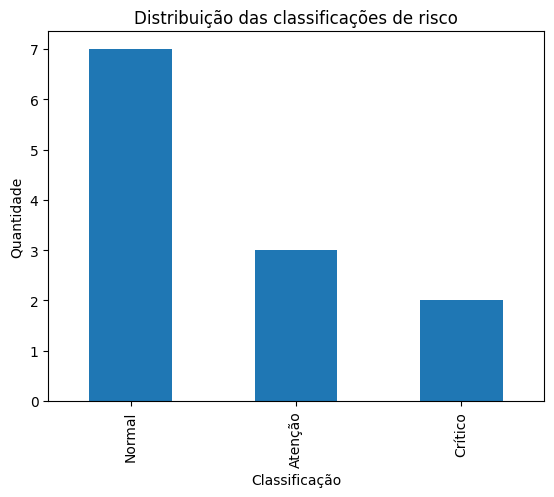

In [12]:
df["classificacao_risco"].value_counts().plot(kind="bar")
plt.title("Distribuição das classificações de risco")
plt.xlabel("Classificação")
plt.ylabel("Quantidade")
plt.show()

### Autonomia estimada por registro
O gráfico abaixo apresenta a autonomia estimada para cada registro da base de dados, considerando o nível de energia disponível, o consumo de decolagem e as perdas energéticas. Essa visualização ajuda a verificar quais cenários apresentam maior limitação energética.

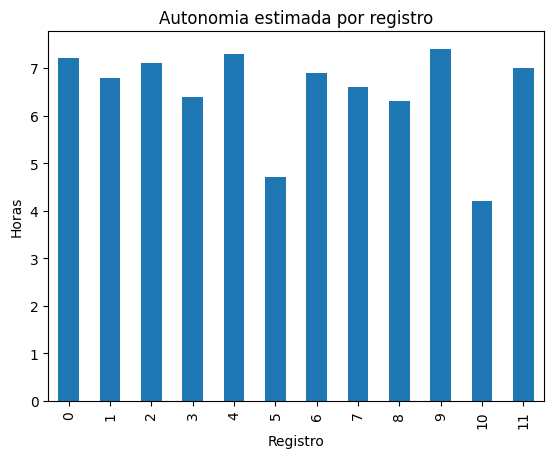

In [13]:
df["autonomia_estimada_horas"].plot(kind="bar")
plt.title("Autonomia estimada por registro")
plt.xlabel("Registro")
plt.ylabel("Horas")
plt.show()

### Índice de prontidão operacional
O gráfico a seguir apresenta o índice de prontidão operacional de cada registro, em uma escala de 0 a 100. Quanto maior o índice, melhores são as condições do sistema para operação no contexto pré-decolagem.

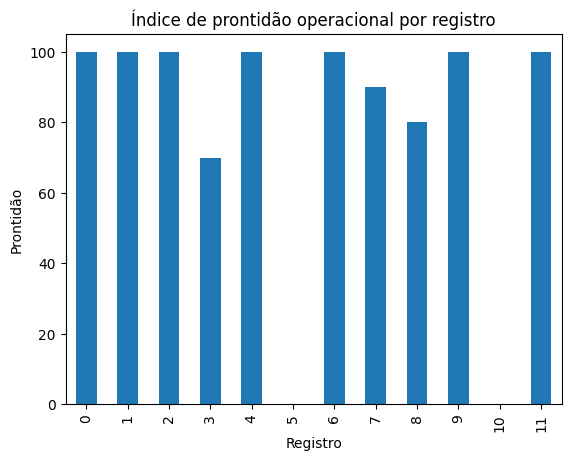

In [14]:
df["indice_prontidao"].plot(kind="bar")
plt.title("Índice de prontidão operacional por registro")
plt.xlabel("Registro")
plt.ylabel("Prontidão")
plt.show()

### Interpretação visual dos resultados
A análise gráfica permite observar a predominância de registros classificados como normais, mas também evidencia a presença de situações de atenção e criticidade. Além disso, os gráficos de autonomia e índice de prontidão ajudam a identificar registros com menor capacidade operacional, reforçando a importância da análise integrada entre energia, integridade estrutural, pressão dos tanques e status dos módulos críticos.

### Resumo quantitativo dos resultados
Além das visualizações gráficas, foi elaborado um resumo quantitativo com indicadores gerais do conjunto de dados, permitindo observar a distribuição das classificações de risco, dos pareceres finais e os valores médios de autonomia e prontidão operacional.

In [15]:
print("Quantidade de registros:", len(df))
print("\nClassificações de risco:")
print(df["classificacao_risco"].value_counts())

print("\nParecer final:")
print(df["parecer_final"].value_counts())

print("\nMédia de autonomia estimada:")
print(df["autonomia_estimada_horas"].mean())

print("\nMédia do índice de prontidão:")
print(df["indice_prontidao"].mean())

Quantidade de registros: 12

Classificações de risco:
classificacao_risco
Normal     7
Atenção    3
Crítico    2
Name: count, dtype: int64

Parecer final:
parecer_final
Sistema apto para operação                  8
Sistema requer revisão antes da operação    2
Sistema não apto para decolagem             2
Name: count, dtype: int64

Média de autonomia estimada:
6.491666666666667

Média do índice de prontidão:
78.33333333333333


### Distribuição do parecer final
O gráfico a seguir apresenta a quantidade de registros classificados em cada categoria de parecer final, permitindo visualizar de forma direta a condição geral do sistema em relação à prontidão operacional.

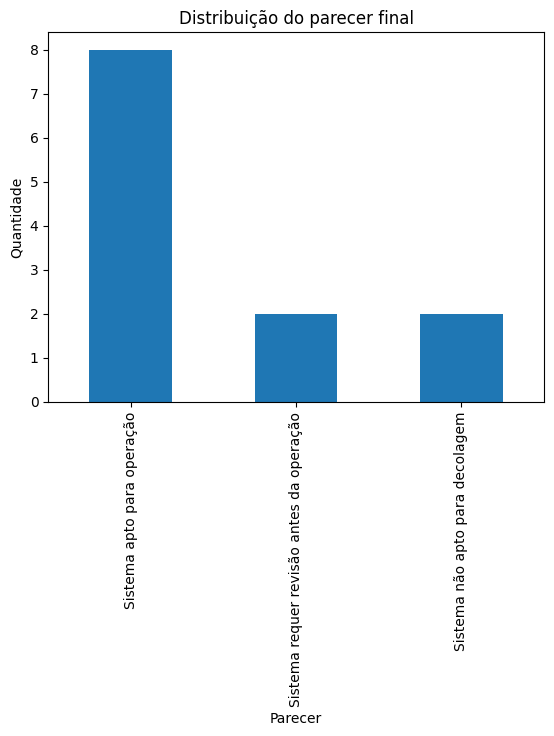

In [16]:
df["parecer_final"].value_counts().plot(kind="bar")
plt.title("Distribuição do parecer final")
plt.xlabel("Parecer")
plt.ylabel("Quantidade")
plt.show()

## Reflexão crítica

Desenvolver este projeto fez com que a análise não ficasse só na parte técnica. Mesmo sendo um cenário simulado, falar de pré-operação de decolagem envolve um contexto delicado, porque qualquer erro de interpretação pode afetar uma decisão importante. Por isso, mais do que criar funções, gráficos e classificações, esse trabalho também leva a pensar sobre responsabilidade, ética, impacto social e sustentabilidade tecnológica.

### Ética e responsabilidade

Sistemas computacionais podem ajudar bastante em situações como essa. Eles organizam os dados, aceleram a análise e deixam a verificação mais padronizada. Isso é uma vantagem, principalmente quando há muitas informações para acompanhar ao mesmo tempo. Porém, esse tipo de ferramenta não pode ser visto como algo que decide sozinho de forma absoluta.

Quando um sistema classifica uma situação como “Normal”, “Atenção” ou “Crítico”, ele influencia diretamente a forma como aquela condição será interpretada. Isso significa que as regras usadas no algoritmo precisam fazer sentido, ser bem definidas e estar claras para quem está utilizando a ferramenta. Se os critérios forem mal escolhidos, o sistema pode passar uma falsa sensação de segurança ou indicar um problema maior do que realmente existe.

Esse ponto é importante porque, em contextos relacionados à segurança, não basta que a tecnologia funcione. Ela também precisa ser compreensível. Foi justamente por isso que, neste projeto, a análise não ficou limitada a uma classificação final. Também foram incluídos o motivo do risco, a identificação de anomalias, o índice de prontidão e o parecer final. A intenção foi tornar o resultado mais interpretável, e não apenas automático.

Outro ponto importante é que a responsabilidade continua sendo humana. Mesmo com apoio da tecnologia, a decisão final não deveria depender somente de um sistema. Ferramentas computacionais ajudam, organizam e orientam, mas ainda precisam ser acompanhadas de análise humana, principalmente quando o contexto é sensível. No fim, a ética nesse tipo de projeto está muito ligada à clareza, ao cuidado com a construção da lógica e ao reconhecimento das limitações do sistema.

### Impacto social da exploração espacial

A exploração espacial costuma ser vista como sinônimo de avanço, inovação e descoberta. E de fato ela está ligada a muitos progressos científicos e tecnológicos. Várias soluções que hoje fazem parte da vida cotidiana tiveram relação, direta ou indireta, com pesquisas espaciais, como sistemas de comunicação, monitoramento por satélite, navegação e desenvolvimento de materiais mais avançados.

Ao mesmo tempo, esse tema também levanta discussões sociais importantes. Nem sempre os benefícios da tecnologia chegam de forma equilibrada para toda a sociedade. Muitas vezes, o acesso à inovação fica concentrado em poucos países, instituições ou empresas, enquanto grande parte da população observa esses avanços de longe, sem participar diretamente deles.

Além disso, também existe a discussão sobre prioridades. Em um mundo com tantos problemas urgentes, como desigualdade, pobreza, crises ambientais e falta de acesso a serviços básicos, é natural questionar como grandes investimentos em tecnologia espacial são justificados. Isso não significa dizer que a exploração espacial não seja importante, mas sim reconhecer que ela precisa ser pensada junto com as necessidades da sociedade.

Nesse sentido, até um projeto acadêmico como este ajuda a enxergar que tecnologia não existe de forma isolada. Por trás de qualquer sistema, mesmo que simples, existem decisões, interesses, recursos e impactos. Pensar sobre o lado social da exploração espacial é importante justamente para não tratar a tecnologia como algo neutro ou distante da realidade.

### Sustentabilidade tecnológica

A sustentabilidade tecnológica também entra nessa discussão. Sistemas aeroespaciais exigem muitos recursos, energia, materiais específicos e uma infraestrutura complexa. Isso mostra que inovação não deve ser medida apenas pelo quanto uma tecnologia consegue fazer, mas também pelo custo que ela gera, pelos recursos que consome e pela sua viabilidade ao longo do tempo.

Muitas vezes, quando se fala em tecnologia, o foco fica só em desempenho e eficiência. Mas isso sozinho não basta. Uma solução também precisa ser sustentável, segura e capaz de funcionar de forma responsável. Pensar dessa maneira é importante porque o desenvolvimento tecnológico não acontece sem impacto.

Dentro deste projeto, a análise energética já ajuda a tocar nesse ponto. Quando o sistema calcula autonomia, perdas e prontidão, ele acaba mostrando que operação eficiente também depende de controle de recursos. Mesmo em uma simulação, isso reforça a ideia de que um sistema precisa ser pensado de forma equilibrada, e não apenas voltada para desempenho máximo.

Também vale lembrar que sustentabilidade tecnológica não envolve apenas meio ambiente. Ela tem relação com manutenção, durabilidade, confiabilidade e possibilidade de evolução. Uma tecnologia que funciona bem hoje, mas é difícil de manter, pouco transparente ou rapidamente descartável, não é uma solução realmente sustentável. Por isso, esse tema vai além de consumo de energia e entra também na forma como as soluções são projetadas e usadas.

### Considerações finais

No fim, este projeto mostra que mesmo uma atividade acadêmica aparentemente técnica pode abrir espaço para reflexões maiores. Organizar dados, classificar riscos e analisar condições operacionais não é apenas uma tarefa de programação. Isso também envolve pensar sobre como a tecnologia é construída, como ela influencia decisões e quais consequências ela pode ter no mundo real.

A principal conclusão dessa reflexão é que ferramentas computacionais podem ser muito úteis, mas não substituem responsabilidade humana. Elas ajudam a interpretar dados, identificar padrões e apoiar decisões, mas continuam dependendo da qualidade das informações, da lógica usada e da forma como os resultados são entendidos.

Por isso, mais do que entregar um sistema funcional, este trabalho também reforça a importância de desenvolver tecnologia com clareza, responsabilidade e senso crítico. No fim das contas, criar uma solução computacional não é só fazer algo funcionar, mas também pensar no impacto que aquilo pode ter e no tipo de uso que se quer dar a essa tecnologia.

## Conclusão
A análise realizada permitiu organizar e interpretar dados de telemetria em um cenário simulado de pré-decolagem. A combinação entre classificação de risco, análise energética, identificação de anomalias e cálculo do índice de prontidão operacional mostrou como ferramentas computacionais podem apoiar decisões em contextos críticos. Os resultados evidenciam que a análise integrada dos parâmetros operacionais contribui para uma avaliação mais clara e segura das condições do sistema.